# 04_feature_analysis — 特徴量分析

実施内容:
- Spearman 相関（目的変数との相関）
- Mutual Information（相互情報量）
- LightGBM Gain 重要度
- SHAP 値
- VIF（分散インフレ係数）
- 高相関特徴量ペア検出

出力:
- `reports/feature_importance.csv`
- `reports/high_correlation.csv`
- `reports/leakage_features.csv`

In [1]:
import sys, json
from pathlib import Path
_NB_DIR = Path().resolve()
if _NB_DIR.name != 'notebooks': _NB_DIR = _NB_DIR.parent
if str(_NB_DIR) not in sys.path: sys.path.insert(0, str(_NB_DIR))
from utils.nb_config import *

_cfg_file = NB_DIR / 'config.json'
if _cfg_file.exists():
    _cfg = json.loads(_cfg_file.read_text(encoding='utf-8'))
    for _k in ('TARGET', 'RANDOM_STATE'): globals()[_k] = _cfg.get(_k, globals()[_k])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Meiryo', 'Yu Gothic', 'MS Gothic', 'DejaVu Sans']
import warnings
warnings.filterwarnings('ignore')

# ── ライブラリバージョン確認 ──────────────────────────────────
import sklearn, lightgbm
print("=== ライブラリバージョン ===")
print(f"  sklearn   : {sklearn.__version__}")
print(f"  lightgbm  : {lightgbm.__version__}")
print(f"  pandas    : {pd.__version__}")
print(f"  numpy     : {np.__version__}")
print(f"  python    : {sys.version.split()[0]}")

# ── TARGET 問題タイプ判定 ──────────────────────────────────────
_REGRESSION_TARGETS = {"speed_deviation", "rank"}
IS_REGRESSION = TARGET in _REGRESSION_TARGETS
print(f"\nTARGET={TARGET!r}  問題タイプ: {'回帰 (Regression)' if IS_REGRESSION else '分類 (Classification)'}")

# 03 の出力を読み込む
import joblib
_cache = NB_DIR / 'data' / 'features' / 'features.pkl'
if not _cache.exists():
    raise FileNotFoundError(f"features.pkl が見つかりません: {_cache}\n"
                            "先に 03_feature_engineering.ipynb を実行してください。")

_data = joblib.load(_cache)
X_train      = _data['X_train']
y_train      = _data['y_train']
X_test       = _data['X_test']
y_test       = _data['y_test']
cat_features = _data['cat_features']

# ── 早期バリデーション ──────────────────────────────────────────
print("\n=== features.pkl 読み込みチェック ===")
print(f"  X_train : {X_train.shape}  dtype={type(X_train).__name__}")
print(f"  y_train : shape={getattr(y_train, 'shape', 'N/A')}  len={len(y_train)}  "
      f"dtype={getattr(y_train, 'dtype', type(y_train).__name__)}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_test  : len={len(y_test)}")

if len(y_train) == 0:
    raise ValueError(
        f"[DATA ERROR] y_train が空 (len=0) です。\n"
        f"  ▸ TARGET='{TARGET}' 列が 03_feature_engineering.ipynb で正しく生成されていません。\n"
        f"  ▸ 03_feature_engineering.ipynb を再実行して features.pkl を再生成してください。"
    )

if len(y_train) != len(X_train):
    raise ValueError(
        f"[DATA ERROR] サイズ不一致: X_train={len(X_train)}, y_train={len(y_train)}\n"
        f"  ▸ 03_feature_engineering.ipynb の train/test 分割ロジックを確認してください。"
    )

if not isinstance(y_train, pd.Series):
    y_train = pd.Series(y_train, name=TARGET)
    print(f"  y_train を pd.Series に変換しました")

_nan_count = y_train.isna().sum()
if IS_REGRESSION:
    print(f"\n  y_train NaN数: {_nan_count}  mean={y_train.mean():.4f}  std={y_train.std():.4f}")
else:
    _pos_rate = y_train.mean() if _nan_count < len(y_train) else float('nan')
    print(f"\n  y_train NaN数: {_nan_count}  正例率: {_pos_rate*100:.1f}%")
print("  ✓ バリデーション OK")


=== ライブラリバージョン ===
  sklearn   : 1.8.0
  lightgbm  : 4.6.0
  pandas    : 2.3.3
  numpy     : 2.3.5
  python    : 3.11.9

TARGET='speed_deviation'  問題タイプ: 回帰 (Regression)

=== features.pkl 読み込みチェック ===
  X_train : (134271, 146)  dtype=DataFrame
  y_train : shape=(134271,)  len=134271  dtype=float32
  X_test  : (36344, 146)
  y_test  : len=36344

  y_train NaN数: 4456  mean=0.0000  std=0.8755
  ✓ バリデーション OK


In [2]:
# ── 1. LightGBM Gain 重要度（TARGET に応じて Classifier/Regressor 自動切替）──
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, mean_squared_error, mean_absolute_error

# ── 前提チェック ──────────────────────────────────────────────
assert len(X_train) > 0,  "X_train が空です。セル1を再実行してください。"
assert len(y_train) > 0,  "y_train が空です。03_feature_engineering.ipynb を再実行してください。"
assert len(X_train) == len(y_train), \
    f"サイズ不一致: X_train={len(X_train)}, y_train={len(y_train)}"

# インデックスをリセット
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# object dtype → category（LightGBM は object 不可）
_obj_cols = X_train.select_dtypes(include='object').columns.tolist()
if _obj_cols:
    X_train[_obj_cols] = X_train[_obj_cols].astype('category')
    X_test[_obj_cols]  = X_test[_obj_cols].astype('category')
    print(f"object→category 変換: {_obj_cols}")

_cat_all = list({c for c in cat_features if c in X_train.columns} |
                {c for c in _obj_cols     if c in X_train.columns})

# y の NaN 行を除去（Classifier/Regressor 両方で必要）
_valid_mask = y_train.notna().values
_nan_rows   = (~_valid_mask).sum()
if _nan_rows > 0:
    print(f"y_train NaN除去: {_nan_rows} 行")

_X_fit = X_train.iloc[_valid_mask].reset_index(drop=True)
_y_fit = y_train.iloc[_valid_mask].reset_index(drop=True)

assert len(_X_fit) > 0, "NaN除去後に学習データが0行になりました。ターゲット列を確認してください。"

# ── TARGET に応じて Classifier / Regressor を選択 ─────────────
if IS_REGRESSION:
    print(f"\n[回帰モード] TARGET={TARGET!r}  fit データ: {len(_X_fit):,} 行  "
          f"y mean={_y_fit.mean():.4f}  std={_y_fit.std():.4f}")
    _lgb_params = {
        'objective':     'regression',
        'metric':        'rmse',
        'n_estimators':  300,
        'learning_rate': 0.05,
        'num_leaves':    63,
        'verbose':       -1,
        'random_state':  RANDOM_STATE,
        'n_jobs':        -1,
    }
    _clf = lgb.LGBMRegressor(**_lgb_params)
else:
    print(f"\n[分類モード] TARGET={TARGET!r}  fit データ: {len(_X_fit):,} 行  "
          f"正例率: {_y_fit.mean()*100:.1f}%")
    _lgb_params = {
        'objective':     'binary',
        'metric':        'auc',
        'n_estimators':  300,
        'learning_rate': 0.05,
        'num_leaves':    63,
        'verbose':       -1,
        'random_state':  RANDOM_STATE,
        'n_jobs':        -1,
    }
    _clf = lgb.LGBMClassifier(**_lgb_params)

_clf.fit(_X_fit, _y_fit, categorical_feature=_cat_all)

# ── テストセット評価 ──────────────────────────────────────────
_valid_test = y_test.notna().values
_X_te_fit   = X_test.iloc[_valid_test].reset_index(drop=True)
_y_te_fit   = y_test.iloc[_valid_test].reset_index(drop=True)

if len(_X_te_fit) > 0:
    _pred = _clf.predict(_X_te_fit)
    if IS_REGRESSION:
        # squared=False は sklearn 1.4 で削除 → np.sqrt(mse) を使用
        _rmse = np.sqrt(mean_squared_error(_y_te_fit, _pred))
        _mae  = mean_absolute_error(_y_te_fit, _pred)
        print(f"テストセット評価 → RMSE={_rmse:.4f}  MAE={_mae:.4f}  n={len(_y_te_fit):,}")
    else:
        try:
            _auc = roc_auc_score(_y_te_fit, _pred)
            print(f"テストセット評価 → AUC={_auc:.4f}  n={len(_y_te_fit):,}")
        except Exception as e:
            print(f"AUC 計算スキップ: {e}")

# ── Gain / Split 重要度 ───────────────────────────────────────
_gain  = pd.Series(_clf.booster_.feature_importance(importance_type='gain'),
                   index=_X_fit.columns).sort_values(ascending=False)
_split = pd.Series(_clf.booster_.feature_importance(importance_type='split'),
                   index=_X_fit.columns).sort_values(ascending=False)

print(f"\nLightGBM Gain 上位20 ({'回帰' if IS_REGRESSION else '分類'}):")
display(_gain.head(20).to_frame('gain'))


y_train NaN除去: 4456 行

[回帰モード] TARGET='speed_deviation'  fit データ: 129,815 行  y mean=0.0000  std=0.8755


テストセット評価 → RMSE=0.7711  MAE=0.6356  n=35,375

LightGBM Gain 上位20 (回帰):


,gain
prev_race_finish,35617.151335
recent_form_weighted,30130.864722
recent_form_5race,28780.366853
race_avg_prev_finish,27027.647716
speed_vs_race_avg,21299.568893
horse_speed_rank_pct,21095.613430
jockey_close_win_rate,11580.526056
venue_encoded,11090.074504
venue_code_encoded,10452.097735
horse_speed_exp_mean,9720.631811


In [3]:
# ── 2. Spearman 相関 ──────────────────────────────────────────
from scipy.stats import spearmanr

_num_cols = X_train.select_dtypes(include='number').columns

# ── 診断: y_train の NaN 状況を確認 ──────────────────────────
_y_nan_count = y_train.isna().sum()
_y_valid_count = y_train.notna().sum()
print(f"y_train: 有効={_y_valid_count:,}  NaN={_y_nan_count:,}  "
      f"NaN率={_y_nan_count/len(y_train)*100:.1f}%")
print(f"数値列: {len(_num_cols)} 列")

# ── 修正版: X と y 両方が非 NaN の行のみ使用 ─────────────────
# 問題: _s.dropna() で X の NaN のみ除去しても y 側の NaN が残る
#       spearmanr は NaN を含む入力に対して (nan, nan) を返す
# 修正: X[c].notna() & y_train.notna() の AND マスクを使用
_y_valid_mask = y_train.notna()

_spearman_rows = []
_skipped = 0
for c in _num_cols:
    # category 型は数値比較できないため float 変換を試みる
    _x_series = X_train[c]
    if hasattr(_x_series, 'cat'):
        try:
            _x_series = _x_series.cat.codes.replace(-1, np.nan).astype(float)
        except Exception:
            _skipped += 1
            continue

    # X と y の両方が有効な行のみ抽出
    _both_valid = _x_series.notna() & _y_valid_mask
    _n_valid = _both_valid.sum()
    if _n_valid < 100:
        _skipped += 1
        continue

    _x_vals = _x_series[_both_valid].values.astype(float)
    _y_vals = y_train[_both_valid].values.astype(float)

    try:
        r, p = spearmanr(_x_vals, _y_vals)
        if np.isnan(r):
            _skipped += 1
            continue
        _spearman_rows.append({
            'feature':    c,
            'spearman_r': round(float(r), 4),
            'p_value':    round(float(p), 6),
            'n_valid':    int(_n_valid),
        })
    except Exception:
        _skipped += 1

print(f"計算成功: {len(_spearman_rows)} 列  スキップ: {_skipped} 列")

_spearman_df = (pd.DataFrame(_spearman_rows)
                .sort_values('spearman_r', key=abs, ascending=False)
                .reset_index(drop=True))
print("Spearman 相関 上位20:")
display(_spearman_df.head(20))


y_train: 有効=129,815  NaN=4,456  NaN率=3.3%
数値列: 145 列


計算成功: 145 列  スキップ: 0 列
Spearman 相関 上位20:


,feature,spearman_r,p_value,n_valid
0,recent_form_weighted,-0.3105,0.0,106597
1,recent_form_5race,-0.3046,0.0,106656
2,prev_race_finish,-0.2970,0.0,105654
3,prev2_race_finish,-0.2172,0.0,96945
4,speed_vs_race_avg,0.2089,0.0,129815
5,top3_count_5,0.2054,0.0,129815
6,jockey_close_win_rate,0.1953,0.0,129815
7,horse_speed_rank_pct,-0.1906,0.0,129815
8,jockey_course_win_rate,0.1860,0.0,129815
9,jockey_field_win_rate,0.1768,0.0,129815


In [4]:
# ── 3. Mutual Information ──────────────────────────────────────
# 回帰ターゲットは mutual_info_regression、分類は mutual_info_classif を使用
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

_X_mi = X_train[_num_cols].fillna(0)

if IS_REGRESSION:
    _mi_scores = mutual_info_regression(_X_mi, y_train.fillna(0), random_state=RANDOM_STATE)
    print("[回帰] mutual_info_regression を使用")
else:
    _mi_scores = mutual_info_classif(_X_mi, y_train, random_state=RANDOM_STATE)
    print("[分類] mutual_info_classif を使用")

_mi_series = pd.Series(_mi_scores, index=_num_cols).sort_values(ascending=False)
print("Mutual Information 上位20:")
display(_mi_series.head(20).to_frame('MI'))


[回帰] mutual_info_regression を使用
Mutual Information 上位20:


,MI
market_entropy,0.314968
race_avg_prev_finish,0.199081
horse_speed_rank_pct,0.169664
distance,0.149647
race_avg_prev_speed,0.149146
venue_encoded,0.144843
num_horses,0.138585
race_max_prev_speed,0.132788
gate_win_rate,0.113145
race_class_encoded,0.112513


SHAP 重要度 上位20 (回帰):


,|SHAP|_mean
race_avg_prev_finish,0.102866
prev_race_finish,0.083173
recent_form_5race,0.067541
horse_speed_rank_pct,0.064219
speed_vs_race_avg,0.062325
recent_form_weighted,0.055212
horse_speed_exp_mean,0.047188
jockey_close_win_rate,0.036271
jt_combo_win_rate_smooth,0.030980
distance_change,0.030872


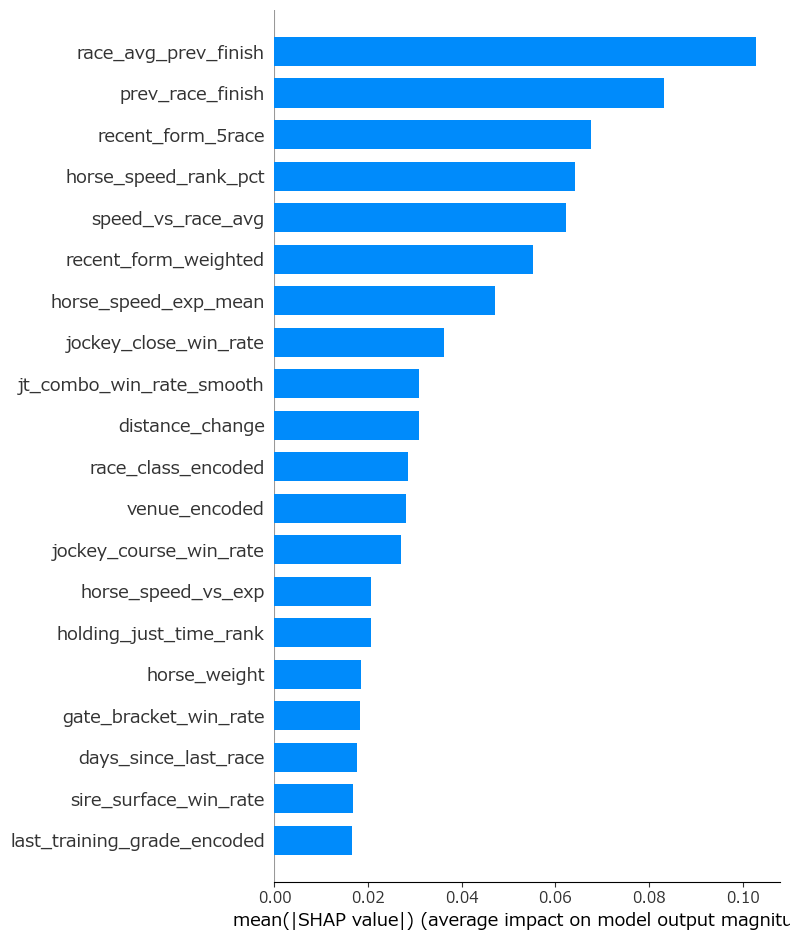

In [5]:
# ── 4. SHAP 値 ────────────────────────────────────────────────
try:
    import shap
    _explainer = shap.TreeExplainer(_clf)
    _sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train),
                                                              min(5000, len(X_train)), replace=False)
    _shap_values = _explainer.shap_values(X_train.iloc[_sample_idx])

    # 分類: list[2] → class=1 を選択 / 回帰: そのまま 2D array
    if isinstance(_shap_values, list):
        _shap_values = _shap_values[1]  # binary classification の positive class

    _shap_mean = np.abs(_shap_values).mean(axis=0)
    _shap_series = pd.Series(_shap_mean, index=X_train.columns).sort_values(ascending=False)

    print(f"SHAP 重要度 上位20 ({'回帰' if IS_REGRESSION else '分類'}):")
    display(_shap_series.head(20).to_frame('|SHAP|_mean'))

    shap.summary_plot(
        _shap_values,
        X_train.iloc[_sample_idx].values,
        feature_names=X_train.columns.tolist(),
        max_display=20,
        show=False,
        plot_type="bar" if IS_REGRESSION else "dot",
    )
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'shap_summary.png', dpi=100, bbox_inches='tight')
    plt.show()
except ImportError:
    print("shap 未インストール: pip install shap")
    _shap_series = pd.Series(dtype=float)


In [6]:
# ── 5. 高相関特徴量ペア検出（Pearson, |r| > 0.90）─────────────
_corr = X_train[_num_cols].fillna(0).corr(method='pearson')
_high_corr = []
for i, col_a in enumerate(_corr.columns):
    for col_b in _corr.columns[i+1:]:
        r = _corr.loc[col_a, col_b]
        if abs(r) >= 0.90:
            _high_corr.append({'A': col_a, 'B': col_b, 'r': round(r, 4)})
_hc_df = pd.DataFrame(_high_corr).sort_values('r', key=abs, ascending=False)
print(f"高相関ペア (|r|≥0.90): {len(_hc_df)} 件")
display(_hc_df.head(20))

_hc_df.to_csv(REPORTS_DIR / 'high_correlation.csv', index=False, encoding='utf-8-sig')
print(f"high_correlation.csv 保存")

高相関ペア (|r|≥0.90): 69 件


,A,B,r
52,prev_race_class_num,prev_class_rank,1.0000
28,class_rank_adj,race_class_rank,0.9999
37,speed_avg_weighted,speed_best_2,0.9997
53,race_avg_prev_speed,race_max_prev_speed,0.9991
58,has_just_data,holding_just_speed,0.9987
43,speed_best_2,speed_best_5,0.9975
38,speed_avg_weighted,speed_best_5,0.9973
65,horse_speed_exp_mean,horse_speed_exp_mean_is_missing,-0.9960
22,holding_just_l3f,has_just_data,0.9946
54,race_avg_prev_speed,race_avg_prev_speed_is_missing,-0.9937


high_correlation.csv 保存


In [7]:
# ── 6. VIF（分散インフレ係数）────────────────────────────────
# 根本原因: category/object 列の .values は numpy object array になり
#           statsmodels の np.isfinite() が TypeError を出す。
# 修正: 純粋な int/float 列のみを対象にし、float64 に統一してから渡す。

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    # ── 純粋な数値列のみ抽出（category/object/bool を除外）─────────
    _vif_candidates = [
        c for c in X_train.columns
        if pd.api.types.is_float_dtype(X_train[c]) or
           pd.api.types.is_integer_dtype(X_train[c])
    ]

    # 分散ゼロの列（定数列）を除外（VIF 計算が singular になる）
    _vif_cols = [c for c in _vif_candidates if X_train[c].std() > 0]

    print(f"VIF 対象: {len(_vif_cols)} 列  "
          f"(全列={len(X_train.columns)}, category等除外={len(X_train.columns)-len(_vif_candidates)}列, "
          f"定数列除外={len(_vif_candidates)-len(_vif_cols)}列)")

    # サンプル制限 + NaN/inf → 0 に置換 + float64 に統一
    _X_vif = (X_train[_vif_cols]
              .head(10000)
              .fillna(0)
              .replace([np.inf, -np.inf], 0)
              .astype(np.float64))   # ← statsmodels が要求する型

    # 診断: 残存する非有限値を確認
    _bad_mask = ~np.isfinite(_X_vif.values)
    if _bad_mask.any():
        _bad_cols = _X_vif.columns[_bad_mask.any(axis=0)].tolist()
        print(f"  ⚠ 非有限値が残っている列: {_bad_cols}")
        _X_vif = _X_vif.drop(columns=_bad_cols)
        _vif_cols = _X_vif.columns.tolist()

    # VIF 計算（列ごとに例外を個別キャッチ）
    _vif_rows = []
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i, col in enumerate(_vif_cols):
            try:
                v = variance_inflation_factor(_X_vif.values, i)
                _vif_rows.append({'feature': col, 'VIF': round(float(v), 2)})
            except Exception as e:
                _vif_rows.append({'feature': col, 'VIF': float('nan')})

    _vif_df = pd.DataFrame(_vif_rows).sort_values('VIF', ascending=False)
    _valid_vif = _vif_df['VIF'].notna()
    print(f"VIF 計算成功: {_valid_vif.sum()} 列  失敗: {(~_valid_vif).sum()} 列")
    print("VIF 上位20:")
    display(_vif_df.head(20))

except ImportError:
    print("statsmodels 未インストール: pip install statsmodels")
    _vif_df = pd.DataFrame()


VIF 対象: 145 列  (全列=146, category等除外=1列, 定数列除外=0列)


VIF 計算成功: 145 列  失敗: 0 列
VIF 上位20:


,feature,VIF
75,prev_race_class_num,inf
81,race_class_rank,inf
82,prev_class_rank,inf
83,class_drop,inf
50,is_female_only_race,inf
76,class_change,inf
53,class_rank_adj,inf
80,class_diff_abs,inf
84,class_up,inf
88,race_avg_prev_speed,29037.07


In [8]:
# ── 7. データリーク候補列の検出 ──────────────────────────────
from keiba_ai.constants import FUTURE_FIELDS
_leak_cols = [c for c in FUTURE_FIELDS if c in X_train.columns]
_leak_df = pd.DataFrame({'feature': _leak_cols, 'reason': 'FUTURE_FIELDS'})
print(f"データリーク候補: {len(_leak_cols)} 列")
display(_leak_df)
_leak_df.to_csv(REPORTS_DIR / 'leakage_features.csv', index=False, encoding='utf-8-sig')
print("leakage_features.csv 保存")

データリーク候補: 0 列


,feature,reason


leakage_features.csv 保存


In [9]:
# ── 8. feature_importance.csv 出力 ───────────────────────────
_gain_total = _gain.sum()
_fi_df = pd.DataFrame({
    'feature':      X_train.columns,
    'lgb_gain':     _gain.reindex(X_train.columns).fillna(0).values,
    'lgb_split':    _split.reindex(X_train.columns).fillna(0).values,
    'spearman_r':   _spearman_df.set_index('feature')['spearman_r'].reindex(X_train.columns).values
                    if not _spearman_df.empty else np.nan,
    'mi':           _mi_series.reindex(X_train.columns).fillna(0).values,
    'shap_mean':    _shap_series.reindex(X_train.columns).fillna(0).values
                    if not _shap_series.empty else np.nan,
}).sort_values('lgb_gain', ascending=False)

_fi_df.to_csv(REPORTS_DIR / 'feature_importance.csv', index=False, encoding='utf-8-sig')
print(f"feature_importance.csv 保存: {len(_fi_df)} 列")
display(_fi_df.head(20))

feature_importance.csv 保存: 146 列


,feature,lgb_gain,lgb_split,spearman_r,mi,shap_mean
8,prev_race_finish,35617.151335,274,-0.2970,0.079705,0.083173
61,recent_form_weighted,30130.864722,275,-0.3105,0.069014,0.055212
70,recent_form_5race,28780.366853,392,-0.3046,0.069645,0.067541
93,race_avg_prev_finish,27027.647716,667,0.0020,0.199081,0.102866
91,speed_vs_race_avg,21299.568893,545,0.2089,0.059780,0.062325
92,horse_speed_rank_pct,21095.613430,216,-0.1906,0.169664,0.064219
127,jockey_close_win_rate,11580.526056,268,0.1953,0.033054,0.036271
140,venue_encoded,11090.074504,760,-0.0018,0.144843,0.028108
141,venue_code_encoded,10452.097735,1141,-0.0021,0.092051,0.008163
128,horse_speed_exp_mean,9720.631811,340,0.0858,0.038328,0.047188


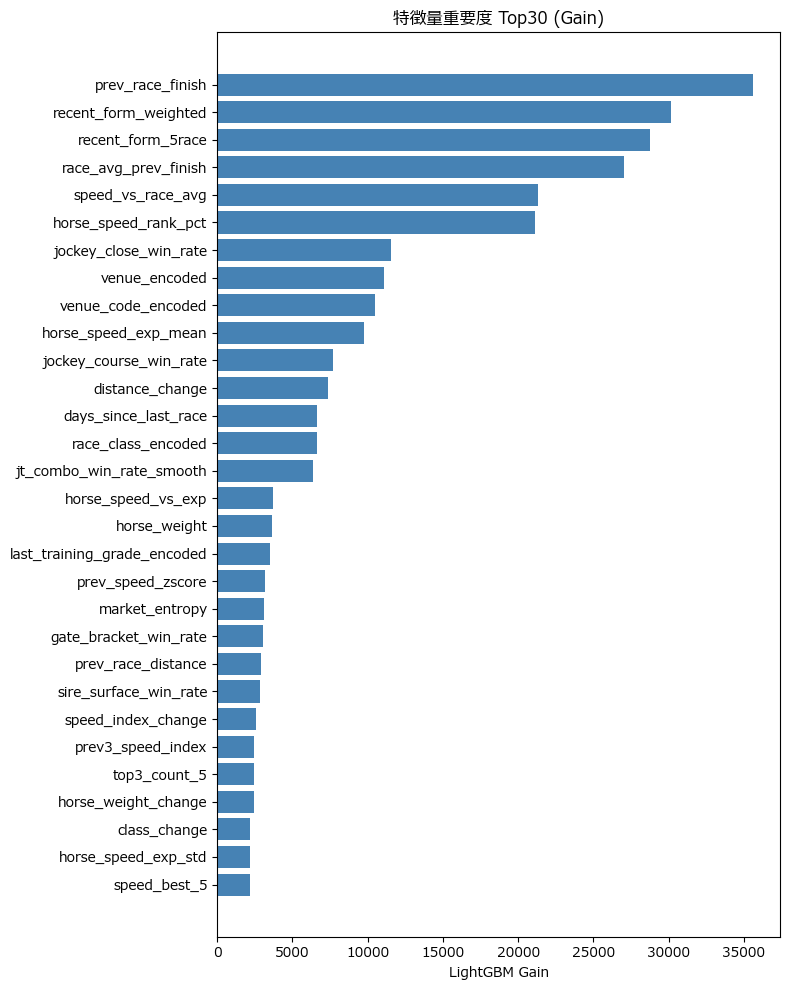

In [10]:
# ── 9. 重要度可視化（上位30）─────────────────────────────────
_top30 = _fi_df.head(30).sort_values('lgb_gain')
fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(_top30['feature'], _top30['lgb_gain'], color='steelblue')
ax.set_xlabel('LightGBM Gain')
ax.set_title('特徴量重要度 Top30 (Gain)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Section 8 — 7段階特徴量ランキング分析（feature_inspection より移行）

`feature_inspection.ipynb` Cells L1–L6 より移行。  
`MODEL_STORE` からモデルバンドルを読み込み、以下の 7 観点でスコアを計算して統合ランキングを作成する。

| ステップ | 内容 | 出力 |
|---|---|---|
| L1 | 品質評価（NaN率・外れ値・リーク疑い） | `quality_df` |
| L2 | 単変量評価（Spearman相関 + 相互情報量） | `univariate_df` |
| L3 | 多重共線性（Pearson高相関ペア + VIF） | `high_corr_df`, `vif_df` |
| L4 | モデルベース重要度（Gain + Permutation + SHAP） | `importance_df` |
| L5 | グループ貢献度 + アブレーション | `group_df`, `ablation_df` |
| L6 | 統合ランキング → `feature_rank_report.csv` | `final_rank_df` |

セル I–K : 剪定シミュレーション → `feature_pruning_report.csv`  
セル OUT : `feature_analysis.json` → FEATURE_STORE


In [11]:
## ── L0: モデルバンドルロード ──────────────────────────────────────────────
print("=== MODEL_STORE 状態確認 ===")
print(f"  パス: {MODEL_STORE}")
_store_files = list(MODEL_STORE.glob("*.pkl")) if MODEL_STORE.exists() else []
if _store_files:
    print(f"  保存済みファイル ({len(_store_files)}件):")
    for _f in sorted(_store_files):
        print(f"    {_f.name}  ({_f.stat().st_size/1024:.1f} KB)")
else:
    print("  ⚠ MODEL_STORE にファイルがありません")
    print("    → 05_model_training.ipynb の TR-H を実行して保存してください")

_bundle_fa = load_store(MODEL_STORE, f"lgb_model_{TARGET}")

if _bundle_fa is not None:
    _model_fa  = _bundle_fa["model"]
    _feat_cols = _bundle_fa["feature_cols"]
    _cat_feats = _bundle_fa["cat_features"]
    _target_fa = _bundle_fa["target"]
    _task_fa   = _bundle_fa["task"]
    _cutoff_fa = pd.Timestamp(_bundle_fa.get("cutoff_date", "2000-01-01"))

    print(f"\nモデル     : {_model_fa.__class__.__name__}  (MODEL_STORE から)")
    print(f"Target     : {_target_fa}  Task: {_task_fa}")
    print(f"Features   : {len(_feat_cols)}")
    print(f"Best iter  : {_bundle_fa.get('best_iteration', 'N/A')}")
    print(f"Metrics    : {_bundle_fa.get('metrics', {})}")

    from keiba_ai.db_ultimate_loader import load_ultimate_training_frame
    from keiba_ai.feature_engineering import add_derived_features
    from keiba_ai.lightgbm_feature_optimizer import LightGBMFeatureOptimizer

    _raw_fa  = load_ultimate_training_frame(get_db_path(DATA_SOURCE_MODE))
    _full_fa = add_derived_features(_raw_fa)
    _full_fa["_date_fa"] = pd.to_datetime(
        _full_fa["race_id"].astype(str).str[:8], format="%Y%m%d", errors="coerce"
    )
    _mask_te_fa = _full_fa["_date_fa"] > _cutoff_fa
    _df_te_fa   = _full_fa[_mask_te_fa].copy().drop(columns=["_date_fa"])
    _full_fa.drop(columns=["_date_fa"], inplace=True)

    _opt_fa = LightGBMFeatureOptimizer()
    _X_fa, _cat_fa2 = _opt_fa.fit_transform(_df_te_fa.copy(), target_col=_target_fa)

    # Bug #4 修正: reindex でモデルと列を完全一致させる（欠落=0埋め）
    _X_fa = _X_fa.reindex(columns=_feat_cols, fill_value=0)

    # object 型列を数値変換（念のため）
    for _c in _X_fa.select_dtypes(include="object").columns:
        _X_fa[_c] = pd.to_numeric(_X_fa[_c], errors="coerce").fillna(0)

    # ターゲット生成
    def _make_target_fa(df, target_col):
        if target_col == "speed_deviation":
            _ts   = pd.to_numeric(df.get("time_seconds",  pd.Series(dtype=float)), errors="coerce")
            _dist = pd.to_numeric(df.get("distance",      pd.Series(dtype=float)), errors="coerce")
            _spd  = _dist / _ts.replace(0, np.nan)
            if "race_id" in df.columns:
                _grp_mean = _spd.groupby(df["race_id"]).transform("mean")
                _grp_std  = _spd.groupby(df["race_id"]).transform("std").replace(0, np.nan)
            else:
                _grp_mean, _grp_std = _spd.mean(), (_spd.std() or np.nan)
            return (_spd - _grp_mean) / _grp_std
        if target_col in df.columns:
            return df[target_col]
        if target_col in ("win", "top3"):
            f = df.get("finish_order", df.get("finish", pd.Series(dtype=float)))
            return (f == 1 if target_col == "win" else f <= 3).astype(int)
        return df.get("speed_index", pd.Series(dtype=float))

    _y_fa = _make_target_fa(_df_te_fa, _target_fa)
    _mask_fa_valid = _y_fa.notna() & _X_fa.notna().all(axis=1)
    _X_fa = _X_fa[_mask_fa_valid].reset_index(drop=True)
    _y_fa = _y_fa[_mask_fa_valid].reset_index(drop=True)
    print(f"\nテストセット: {len(_X_fa):,} 行 × {len(_X_fa.columns)} 列")

else:
    print("\n[フォールバック] セル3の _clf / X_train / y_train を使用します")

    _model_fa  = _clf
    _feat_cols = X_train.columns.tolist()
    _cat_feats = _cat_all
    _target_fa = TARGET
    _task_fa   = "regression" if IS_REGRESSION else "classification"
    _cutoff_fa = pd.Timestamp("2000-01-01")

    _bundle_fa = {
        "model"           : _model_fa,
        "feature_cols"    : _feat_cols,
        "cat_features"    : _cat_feats,
        "target"          : _target_fa,
        "task"            : _task_fa,
        "metrics"         : {},
        "best_iteration"  : getattr(_model_fa, 'best_iteration_', 'N/A'),
        "params"          : _lgb_params,
        "feature_importance": None,
        "cutoff_date"     : str(_cutoff_fa.date()),
    }

    _X_fa = X_test.copy()
    _y_fa = y_test.copy()

    _y_valid = _y_fa.notna().values
    _X_fa = _X_fa.iloc[_y_valid].reset_index(drop=True)
    _y_fa = _y_fa.iloc[_y_valid].reset_index(drop=True)

    print(f"\nモデル     : {_model_fa.__class__.__name__}  (フォールバック)")
    print(f"Target     : {_target_fa}  Task: {_task_fa}")
    print(f"Features   : {len(_feat_cols)}")
    print(f"テストセット: {len(_X_fa):,} 行 × {len(_X_fa.columns)} 列")


=== MODEL_STORE 状態確認 ===
  パス: C:\Users\yuki2\Documents\ws\keiba-ai-pro\notebooks\data\model_store
  保存済みファイル (1件):
    lgb_model_speed_deviation.pkl  (1429.1 KB)
  ✓ model_store/lgb_model_speed_deviation.pkl ロード (1429.1 KB)

モデル     : Booster  (MODEL_STORE から)
Target     : speed_deviation  Task: regression
Features   : 105
Best iter  : 0
Metrics    : {'rmse': 0.9581, 'corr': 0.4196}
→ Ultimate DBからデータ読み込み: C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\data\keiba_ultimate.db
  絶対パス: C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\data\keiba_ultimate.db
  存在チェック: True


  ✓ return_tables_ultimate: 50155レースの配当情報をロード


  ✓ holding_times_cache: 23969レース（バックフィル用）
  ✓ 575346行取得


  ✓ DataFrame変換: 575346行 × 123列


  ✓ num_horses: 欠損なし (575346件)
  ✓ venue コード解決: 573039件


  ✓ prev_race_class (ラグ): 510,812/575,346件 (88.8%)


  ✓ 型変換完了: 数値=72列, 文字列=3列, 合計=132列
  ✓ category: 57列
  ✓ distance: 575346件取得
  ✓ surface: 575346件取得
  ✓ メモリ最適化: 2641.24MB -> 338.98MB (2302.26MB, 87.17%)


  ⚠ [L3-1] 未来情報列を除外 (25列): ['finish', 'finish_position', 'corner_position_variance', 'corner_positions', 'last_3f_rank', 'corner_first', 'last_3f_time', 'last_3f', 'corner_2', 'time_seconds', 'corner_position_avg', 'last_corner_position', 'corner_3', 'corner_positions_list', 'finish_time', 'running_style_code', 'margin', 'last_3f_rank_normalized', 'corner_gain', 'corner_last', 'corner_4', 'position_change', 'corner_1', 'time_index', 'prize_money']

【LightGBM特徴量最適化】学習モード

【1. 低カーディナリティ カテゴリカル変数】
処理: Label Encoding → LightGBMのcategorical_feature指定
  ✓ venue                          → venue_encoded                  (3種類)
  ✓ venue_code                     → venue_code_encoded             (10種類)
  ✓ track_type                     → track_type_encoded             (3種類)
  ✓ surface                        → surface_encoded                (3種類)
  ✓ weather                        → weather_encoded                (4種類)
  ✓ field_condition                → field_condition_encoded        (5種類)
  ✓

In [12]:
## ── L1: 品質評価（NaN率・外れ値・リーク疑い）─────────────────────────────
# feature_inspection.ipynb Cell L1 より移行

from keiba_ai.constants import FUTURE_FIELDS, UNNECESSARY_COLUMNS

_quality_rows = []
for col in _feat_cols:
    if col not in _X_fa.columns:
        _quality_rows.append({"feature": col, "nan_%": 100.0, "outlier_%": 0.0,
                               "is_leak": col in FUTURE_FIELDS, "quality_score": 0.0})
        continue
    s = _X_fa[col]
    nan_pct = s.isna().mean() * 100
    if pd.api.types.is_numeric_dtype(s) and s.notna().any():
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        outlier_pct = ((s < q1 - 3*iqr) | (s > q3 + 3*iqr)).mean() * 100 if iqr > 0 else 0.0
    else:
        outlier_pct = 0.0
    is_leak  = col in FUTURE_FIELDS
    # 品質スコア: 高いほど良い（0〜1）
    quality_score = max(0.0, 1.0 - nan_pct/100 - outlier_pct/200 - (0.5 if is_leak else 0.0))
    _quality_rows.append({
        "feature"      : col,
        "nan_%"        : round(nan_pct, 2),
        "outlier_%"    : round(outlier_pct, 2),
        "is_leak"      : is_leak,
        "quality_score": round(quality_score, 4),
    })

quality_df = pd.DataFrame(_quality_rows).sort_values("quality_score", ascending=True)
print(f"品質スコア < 0.5 の列: {(quality_df['quality_score'] < 0.5).sum()}")
display(quality_df[quality_df["quality_score"] < 0.8].style
        .background_gradient(subset=["nan_%", "outlier_%"], cmap="Reds")
        .background_gradient(subset=["quality_score"], cmap="Greens")
        .set_caption("品質注意列（quality_score < 0.8）"))


品質スコア < 0.5 の列: 0


,feature,nan_%,outlier_%,is_leak,quality_score


In [13]:
## ── L2: 単変量評価（Spearman + 相互情報量）──────────────────────────────
# feature_inspection.ipynb Cell L2 より移行
#
# 根本原因: _X_fa に category 型列が含まれており
#   category_series.fillna(0) → 0 がカテゴリに未登録 → TypeError
# 修正方針:
#   数値列  → pd.to_numeric で float 変換
#   category → .cat.codes で整数化 (-1=NaN として扱う)
#   object  → pd.factorize で整数化
#   全列で NaN/inf を除去した上で Spearman / MI を計算

from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

_valid_feats = [c for c in _feat_cols if c in _X_fa.columns]
_y_arr = _y_fa.values.astype(float)
_y_valid_mask_l2 = np.isfinite(_y_arr)   # NaN/inf 行を除外

print(f"単変量評価 ({len(_valid_feats)} 列)…")
print(f"  y_fa 有効行: {_y_valid_mask_l2.sum():,} / {len(_y_arr):,}")

# ── 安全な列変換ヘルパー ─────────────────────────────────────
def _to_float_safe(series: pd.Series) -> pd.Series:
    """category/object/数値を問わず float Series に変換する。
    変換不能な値は NaN になる。"""
    if hasattr(series, 'cat'):
        # category → codes (未知カテゴリ/NaN は -1)
        codes = series.cat.codes.astype(float)
        codes[codes == -1] = np.nan
        return codes
    elif series.dtype == object:
        # object → factorize (-1 を NaN に)
        codes, _ = pd.factorize(series, na_sentinel=-1)
        result = codes.astype(float)
        result[result == -1] = np.nan
        return pd.Series(result, index=series.index)
    else:
        return pd.to_numeric(series, errors='coerce')

# ── Spearman 相関 ─────────────────────────────────────────────
_univariate_rows = []
_skipped_l2 = 0

for col in _valid_feats:
    _x_float = _to_float_safe(_X_fa[col])

    # X と y の両方が有限な行のみ使用
    _both_valid = np.isfinite(_x_float.values) & _y_valid_mask_l2
    _n_valid = int(_both_valid.sum())
    if _n_valid < 100:
        _skipped_l2 += 1
        _univariate_rows.append({"feature": col, "spearman_rho": 0.0})
        continue

    try:
        rho, _ = spearmanr(_x_float.values[_both_valid], _y_arr[_both_valid])
        rho = 0.0 if np.isnan(rho) else float(rho)
    except Exception:
        rho = 0.0
    _univariate_rows.append({"feature": col, "spearman_rho": round(rho, 4)})

print(f"  Spearman 計算: {len(_univariate_rows)-_skipped_l2} 列成功  {_skipped_l2} 列スキップ(n<100)")

_uni_df_tmp = pd.DataFrame(_univariate_rows)

# ── Mutual Information ─────────────────────────────────────────
# category/object 列を安全に float 変換してから MI 計算
_X_mi_rows = {}
for col in _valid_feats:
    _x_float = _to_float_safe(_X_fa[col])
    # NaN/inf → 0 で補完（MI は全行同一サイズが必要）
    _x_filled = np.where(np.isfinite(_x_float.values), _x_float.values, 0.0)
    _X_mi_rows[col] = _x_filled

_X_mi_arr = np.column_stack([_X_mi_rows[c] for c in _valid_feats])

# y も NaN を 0 で補完（MI では全行を使う）
_y_mi = np.where(_y_valid_mask_l2, _y_arr, 0.0)

_mi_fn = mutual_info_regression if _task_fa == "regression" else mutual_info_classif
_mi_scores = _mi_fn(_X_mi_arr, _y_mi, random_state=RANDOM_STATE, discrete_features=False)
_uni_df_tmp["mi_score"] = [round(float(v), 4) for v in _mi_scores]
print(f"  MI 計算: {len(_valid_feats)} 列 ({'mutual_info_regression' if _task_fa=='regression' else 'mutual_info_classif'})")

# ── スコア正規化 (0〜1) ────────────────────────────────────────
_uni_df_tmp["spearman_abs"] = _uni_df_tmp["spearman_rho"].abs()
_max_spearman = max(_uni_df_tmp["spearman_abs"].max(), 1e-9)
_max_mi       = max(_uni_df_tmp["mi_score"].max(), 1e-9)
_uni_df_tmp["mi_norm"]  = (_uni_df_tmp["mi_score"] / _max_mi).round(4)
_uni_df_tmp["uni_score"] = (
    0.5 * _uni_df_tmp["spearman_abs"] / _max_spearman +
    0.5 * _uni_df_tmp["mi_norm"]
).round(4)

univariate_df = _uni_df_tmp.sort_values("uni_score", ascending=False).reset_index(drop=True)
print(f"\n単変量評価 top-10:")
display(univariate_df.head(10).style
        .background_gradient(subset=["spearman_abs","mi_norm","uni_score"], cmap="Blues")
        .set_caption("単変量評価 top-10"))


単変量評価 (105 列)…
  y_fa 有効行: 41 / 41
  Spearman 計算: 0 列成功  105 列スキップ(n<100)
  MI 計算: 105 列 (mutual_info_regression)

単変量評価 top-10:


,feature,spearman_rho,mi_score,spearman_abs,mi_norm,uni_score
0,rest_category,0.000000,0.220900,0.000000,1.000000,0.500000
1,speed_trend_5,0.000000,0.170200,0.000000,0.770500,0.385200
2,num_horses,0.000000,0.159700,0.000000,0.723000,0.361500
3,form_trend,0.000000,0.150000,0.000000,0.679000,0.339500
4,prev4_race_finish,0.000000,0.143900,0.000000,0.651400,0.325700
5,holding_just_l3f,0.000000,0.142700,0.000000,0.646000,0.323000
6,prev_race_finish,0.000000,0.138500,0.000000,0.627000,0.313500
7,holding_short_time_sec,0.000000,0.117200,0.000000,0.530600,0.265300
8,recent_form_weighted,0.000000,0.111900,0.000000,0.506600,0.253300
9,prev_speed_index,0.000000,0.092300,0.000000,0.417800,0.208900


In [14]:
## ── L3: 多重共線性（高相関ペア + VIF）────────────────────────────────────
# feature_inspection.ipynb Cell L3 より移行

CORR_THRESHOLD = 0.90   # 高相関ペアの閾値

_num_feats_fa = [c for c in _valid_feats if pd.api.types.is_numeric_dtype(_X_fa[c])]
_corr_matrix  = _X_fa[_num_feats_fa].fillna(0).corr(method="pearson").abs()

# 高相関ペア抽出
_high_corr_rows = []
for i in range(len(_num_feats_fa)):
    for j in range(i + 1, len(_num_feats_fa)):
        c = _corr_matrix.iloc[i, j]
        if c >= CORR_THRESHOLD:
            _high_corr_rows.append({
                "feature_a": _num_feats_fa[i],
                "feature_b": _num_feats_fa[j],
                "pearson_r": round(float(c), 4),
            })
high_corr_df = pd.DataFrame(_high_corr_rows).sort_values("pearson_r", ascending=False)
print(f"高相関ペア (≥{CORR_THRESHOLD}): {len(high_corr_df)} ペア")
if len(high_corr_df):
    display(high_corr_df.head(20).style
            .background_gradient(subset=["pearson_r"], cmap="Reds")
            .set_caption(f"高相関ペア top-20 (閾値={CORR_THRESHOLD})"))

# VIF 計算（列数が多い場合は top-50 Gain 列のみ）
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

_imp_for_vif = _bundle_fa.get("feature_importance")
if _imp_for_vif is not None:
    _vif_cols = (_imp_for_vif.sort_values("gain", ascending=False)["feature"]
                 .head(50).tolist())
    _vif_cols = [c for c in _vif_cols if c in _num_feats_fa]
else:
    _vif_cols = _num_feats_fa[:50]

_Xvif = _X_fa[_vif_cols].fillna(0)
_vif_rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for idx, col in enumerate(_vif_cols):
        try:
            v = variance_inflation_factor(_Xvif.values, idx)
        except Exception:
            v = float("nan")
        _vif_rows.append({"feature": col, "vif": round(float(v), 2)})

vif_df = pd.DataFrame(_vif_rows).sort_values("vif", ascending=False)
print(f"\nVIF > 10 の列: {(vif_df['vif'] > 10).sum()}")
display(vif_df[vif_df["vif"] > 5].style
        .background_gradient(subset=["vif"], cmap="Oranges")
        .set_caption("VIF > 5 の列（top-50 Gain 内）"))


高相関ペア (≥0.9): 42 ペア


,feature_a,feature_b,pearson_r
7,kai,kai_sin,1.000000
8,kai,venue_encoded,1.000000
34,kai_sin,venue_encoded,1.000000
10,day,venue_code_encoded,1.000000
20,holding_just_time_sec,holding_middle_time_sec,0.999300
21,holding_just_time_sec,holding_short_time_sec,0.995300
23,holding_middle_time_sec,holding_short_time_sec,0.994900
1,distance,holding_middle_time_sec,0.992600
0,distance,holding_just_time_sec,0.992400
18,prev5_race_time,prev5_race_distance,0.991100



VIF > 10 の列: 50


,feature,vif
0,recent_form_5race,inf
1,recent_form_weighted,inf
2,prev_race_finish,inf
3,race_avg_prev_finish,inf
4,horse_speed_rank_pct,inf
5,distance_change,inf
6,race_class_encoded,inf
7,speed_vs_race_avg,inf
8,prev2_race_finish,inf
9,top3_count_5,inf


In [15]:
## ── L4: モデルベース重要度（Gain + Permutation + SHAP）────────────────────
# feature_inspection.ipynb Cell L4 より移行

import shap
from sklearn.inspection import permutation_importance
import numpy as np

# ── Gain 重要度（モデルバンドル内 or 再取得）─────────────────────────────
_gain_df_fa = _bundle_fa.get("feature_importance")
if _gain_df_fa is None:
    # LGBMRegressor/Classifier (sklearn API) は .booster_ 経由で Booster にアクセス
    # lgb.Booster (ネイティブ API) の場合はそのまま呼び出し可能
    if hasattr(_model_fa, "booster_"):
        # sklearn API (LGBMRegressor / LGBMClassifier)
        _booster = _model_fa.booster_
    else:
        # ネイティブ Booster
        _booster = _model_fa
    _gain_arr = _booster.feature_importance(importance_type="gain")
    _gain_df_fa = pd.DataFrame({"feature": _booster.feature_name(), "gain": _gain_arr})

_gain_norm_max = _gain_df_fa["gain"].max() or 1e-9
_gain_df_fa["gain_norm"] = (_gain_df_fa["gain"] / _gain_norm_max).round(4)

# ── Permutation 重要度（サンプル 5,000 行で近似）────────────────────────
print("Permutation importance 計算中…")
_n_perm = min(5000, len(_X_fa))
_rng_perm = np.random.default_rng(RANDOM_STATE)
_perm_idx  = _rng_perm.choice(len(_X_fa), _n_perm, replace=False)
_X_perm    = _X_fa.iloc[_perm_idx].reset_index(drop=True)
_y_perm    = _y_fa.iloc[_perm_idx].reset_index(drop=True)

from sklearn.base import BaseEstimator
class _LGBWrapper(BaseEstimator):
    def __init__(self, model): self.model = model
    def fit(self, X, y): pass
    def predict(self, X): return self.model.predict(X)
    def score(self, X, y):
        from sklearn.metrics import roc_auc_score, mean_squared_error
        p = self.predict(X)
        try:
            return roc_auc_score(y, p)
        except Exception:
            # squared=False は sklearn 1.4 で削除 → np.sqrt(mse) を使用
            return -float(np.sqrt(mean_squared_error(y, p)))

_lgbw = _LGBWrapper(_model_fa)
_pi = permutation_importance(_lgbw, _X_perm, _y_perm,
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
_perm_scores = _pi.importances_mean
_perm_scores = np.clip(_perm_scores, 0, None)  # 負を0に
_perm_max = _perm_scores.max() or 1e-9
_perm_norm = (_perm_scores / _perm_max)
_perm_df_fa = pd.DataFrame({"feature": _X_fa.columns.tolist(),
                             "perm_imp": _perm_scores.round(4),
                             "perm_norm": _perm_norm.round(4)})
print("  完了")

# ── SHAP 重要度（サンプル 3,000 行）─────────────────────────────────────
print("SHAP 重要度 計算中…")
_n_shap = min(3000, len(_X_fa))
_shap_idx  = _rng_perm.choice(len(_X_fa), _n_shap, replace=False)
_X_shap_fa = _X_fa.iloc[_shap_idx].reset_index(drop=True)
_explainer_fa = shap.TreeExplainer(_model_fa)
_shap_vals = _explainer_fa.shap_values(_X_shap_fa)
if isinstance(_shap_vals, list):
    _shap_vals = _shap_vals[1]  # binary の場合 class=1
_shap_mean = np.abs(_shap_vals).mean(axis=0)
_shap_max  = _shap_mean.max() or 1e-9
_shap_df_fa = pd.DataFrame({"feature": _X_fa.columns.tolist(),
                             "shap_mean": _shap_mean.round(4),
                             "shap_norm": (_shap_mean / _shap_max).round(4)})
print("  完了")

# ── 統合重要度 DataFrame ──────────────────────────────────────────────────
importance_df = (_gain_df_fa[["feature","gain_norm"]]
                 .merge(_perm_df_fa[["feature","perm_norm"]], on="feature", how="left")
                 .merge(_shap_df_fa[["feature","shap_norm"]], on="feature", how="left")
                 .fillna(0))
importance_df["imp_score"] = (
    0.4 * importance_df["gain_norm"] +
    0.3 * importance_df["perm_norm"] +
    0.3 * importance_df["shap_norm"]
).round(4)
importance_df.sort_values("imp_score", ascending=False, inplace=True)
importance_df.reset_index(drop=True, inplace=True)

display(importance_df.head(20).style
        .background_gradient(subset=["gain_norm","perm_norm","shap_norm","imp_score"], cmap="Blues")
        .set_caption("モデルベース重要度 top-20"))


Permutation importance 計算中…


  完了
SHAP 重要度 計算中…


  完了


,feature,gain_norm,perm_norm,shap_norm,imp_score
0,recent_form_5race,1.000000,1.000000,1.000000,1.000000
1,recent_form_weighted,0.760500,0.844800,0.741200,0.780000
2,prev_race_finish,0.302800,0.512600,0.372200,0.386600
3,horse_speed_rank_pct,0.092500,0.176600,0.189700,0.146900
4,race_avg_prev_finish,0.098700,0.000000,0.319400,0.135300
5,distance_change,0.055200,0.000000,0.155600,0.068800
6,speed_vs_race_avg,0.047000,0.091000,0.069900,0.067100
7,top3_count_5,0.039000,0.079300,0.065300,0.059000
8,race_class_encoded,0.047800,0.000000,0.117800,0.054500
9,prev3_race_finish,0.023500,0.077500,0.065400,0.052300


In [16]:
## ── L5: グループ貢献度 ────────────────────────────────────────────────────
# feature_inspection.ipynb Cell L5 より移行
# FEATURE_GROUPS_FA をここで定義（02 の FEATURE_GROUPS_FI と同じ内容）

FEATURE_GROUPS_FA = {
    "01_レース基本情報": ["race_class_num","venue_code","race_num","n_horses","cos_date","sin_date",
                          "season","sex_code","frame_race_type","class_rank_adj","weight_vs_standard"],
    "02_コース特性":     ["straight_length","track_type","corner_radius","inner_bias","inner_advantage"],
    "03_馬属性・休養":   ["is_young","is_prime","is_veteran","running_style_num",
                          "rest_short","rest_normal","rest_long","rest_very_long"],
    "04_オッズ市場":     ["implied_prob","log_odds","odds_is_missing","implied_prob_norm",
                          "odds_rank_in_race","odds_z_in_race","market_entropy","top3_probability","popularity_normalized"],
    "05_前走・近走":     ["days_since_last_race","distance_change","prev_speed_index","prev_speed_zscore",
                          "speed_index_change","recent_form_weighted","form_trend","recent_form_5race",
                          "win_count_5","top3_count_5","prev_race_class_num","class_change"],
    "06_相手関係":       ["race_avg_prev_speed","race_max_prev_speed","speed_vs_race_avg","horse_speed_rank_pct"],
    "07_持ちタイム":     ["has_just_data","holding_just_speed","holding_just_time_rank"],
    "08_ラップ展開":     ["lap_200m","lap_400m","lap_600m","race_pace_front","race_pace_back","race_pace_diff"],
    "09_脚質":           ["corner_first","corner_last","corner_gain","running_style_code"],
    "10_速度指数":       ["sf_index_last","sf_index_2ago","sf_max_index","sf_course_max_index","sf_index_trend"],
    "11_調教":           ["last_training_time_3f","has_training_data","last_training_grade_encoded"],
    "12_通算統計":       ["horse_win_rate_exp","horse_show_rate_exp","jockey_win_rate","jockey_show_rate",
                          "trainer_win_rate","trainer_show_rate","sire_win_rate","gate_bracket_win_rate"],
    "13_欠損フラグ":     [c for c in _feat_cols if c.endswith("_is_missing")],
}

_group_rows = []
for grp, cols in FEATURE_GROUPS_FA.items():
    _gcols = [c for c in cols if c in _feat_cols]
    if not _gcols:
        continue
    _gimp = importance_df[importance_df["feature"].isin(_gcols)]["imp_score"]
    _group_rows.append({
        "group"    : grp,
        "n_feats"  : len(_gcols),
        "avg_score": round(_gimp.mean(), 4) if len(_gimp) else 0.0,
        "sum_score": round(_gimp.sum(), 4)  if len(_gimp) else 0.0,
        "max_score": round(_gimp.max(), 4)  if len(_gimp) else 0.0,
    })

group_df = pd.DataFrame(_group_rows).sort_values("sum_score", ascending=False)
print("グループ別貢献度:")
display(group_df.style
        .background_gradient(subset=["sum_score","max_score"], cmap="Greens")
        .set_caption("グループ別 imp_score 集計"))


グループ別貢献度:


,group,n_feats,avg_score,sum_score,max_score
2,05_前走・近走,12,0.171500,2.058300,1.000000
3,06_相手関係,4,0.056800,0.227400,0.146900
0,01_レース基本情報,6,0.006700,0.040200,0.018700
4,07_持ちタイム,3,0.011800,0.035500,0.035000
1,04_オッズ市場,1,0.007300,0.007300,0.007300
5,13_欠損フラグ,7,0.000300,0.001900,0.000700


In [17]:
## ── L6: 統合ランキング → feature_rank_report.csv ──────────────────────────
# feature_inspection.ipynb Cell L6 より移行

# スコア統合（L1 品質 × L2 単変量 × L4 モデル重要度）
final_rank_df = (importance_df[["feature","imp_score"]]
                 .merge(univariate_df[["feature","uni_score","spearman_rho"]], on="feature", how="left")
                 .merge(quality_df[["feature","quality_score","nan_%"]], on="feature", how="left")
                 .fillna(0))

# 総合スコア (imp × quality × uni)
final_rank_df["final_score"] = (
    0.5  * final_rank_df["imp_score"] +
    0.3  * final_rank_df["uni_score"] +
    0.2  * final_rank_df["quality_score"]
).round(4)

# グループ列を付与
_col2grp = {}
for grp, cols in FEATURE_GROUPS_FA.items():
    for c in cols:
        _col2grp[c] = grp

final_rank_df["group"] = final_rank_df["feature"].map(_col2grp).fillna("99_その他")

# VIF フラグ
_high_vif_set = set(vif_df[vif_df["vif"] > 10]["feature"]) if len(vif_df) else set()
final_rank_df["high_vif"] = final_rank_df["feature"].isin(_high_vif_set)

# 高相関ペアフラグ
_high_corr_set = set(high_corr_df["feature_a"]) | set(high_corr_df["feature_b"]) if len(high_corr_df) else set()
final_rank_df["high_corr"] = final_rank_df["feature"].isin(_high_corr_set)

final_rank_df.sort_values("final_score", ascending=False, inplace=True)
final_rank_df.reset_index(drop=True, inplace=True)
final_rank_df.insert(0, "rank", final_rank_df.index + 1)

print(f"特徴量ランキング完成: {len(final_rank_df)} 列")
display(final_rank_df.head(30).style
        .background_gradient(subset=["final_score","imp_score","uni_score"], cmap="Blues")
        .apply(lambda col: ["color:#E45756" if v else "" for v in col], subset=["high_vif","high_corr"])
        .set_caption("統合特徴量ランキング top-30"))

# CSV 保存
_rank_csv = REPORTS_DIR / "feature_rank_report.csv"
final_rank_df.to_csv(_rank_csv, index=False, encoding="utf-8-sig")
print(f"\n✓ 保存: {_rank_csv}")


特徴量ランキング完成: 105 列


,rank,feature,imp_score,uni_score,spearman_rho,quality_score,nan_%,final_score,group,high_vif,high_corr
0,1,recent_form_5race,1.000000,0.207100,0.000000,1.000000,0.000000,0.762100,05_前走・近走,True,True
1,2,recent_form_weighted,0.780000,0.253300,0.000000,1.000000,0.000000,0.666000,05_前走・近走,True,True
2,3,prev_race_finish,0.386600,0.313500,0.000000,1.000000,0.000000,0.487400,99_その他,True,False
3,4,rest_category,0.000000,0.500000,0.000000,1.000000,0.000000,0.350000,99_その他,False,False
4,5,form_trend,0.024700,0.339500,0.000000,1.000000,0.000000,0.314200,05_前走・近走,True,False
5,6,speed_trend_5,0.001200,0.385200,0.000000,0.987800,0.000000,0.313700,99_その他,True,False
6,7,num_horses,0.000900,0.361500,0.000000,1.000000,0.000000,0.308900,99_その他,False,False
7,8,prev4_race_finish,0.010200,0.325700,0.000000,1.000000,0.000000,0.302800,99_その他,True,False
8,9,holding_just_l3f,0.000600,0.323000,0.000000,1.000000,0.000000,0.297200,99_その他,False,False
9,10,speed_vs_race_avg,0.067100,0.192100,0.000000,0.987800,0.000000,0.288700,06_相手関係,True,False



✓ 保存: C:\Users\yuki2\Documents\ws\keiba-ai-pro\notebooks\reports\feature_rank_report.csv


---
## Section 9 — 剪定シミュレーション（feature_inspection Cells I-K より移行）

低重要度特徴量を段階的に除去したとき、AUC/RMSE がどう変化するかをシミュレーションする。

- Cell I : 剪定候補リスト生成
- Cell J : 段階除去 × CV でスコア計算
- Cell K : 可視化 + `feature_pruning_report.csv`


In [18]:
## ── Cell I: 剪定候補リスト生成 ───────────────────────────────────────────
# feature_inspection.ipynb Cell I より移行

# ── パラメータ ─────────────────────────────────────────────────────────────
PRUNE_SCORE_THRESHOLD = 0.05  # final_score がこれ未満は剪定候補
PRUNE_CORR_MIN_GAIN   = 0.10  # 高相関ペアで低い方を除去（gain_norm 閾値）
MIN_FEATURES_KEEP     = 20    # 最低維持列数

# ── 剪定候補分類 ──────────────────────────────────────────────────────────
_keep_feats   = []
_prune_low    = []  # スコア低
_prune_corr   = []  # 高相関ペアの低重要度側
_prune_vif    = []  # VIF 高

# 高相関ペアで除去対象を決定（low gain を除去）
_corr_remove = set()
for _, row in high_corr_df.iterrows():
    fa, fb = row["feature_a"], row["feature_b"]
    _ga = final_rank_df[final_rank_df["feature"] == fa]["imp_score"].values
    _gb = final_rank_df[final_rank_df["feature"] == fb]["imp_score"].values
    _ga = float(_ga[0]) if len(_ga) else 0.0
    _gb = float(_gb[0]) if len(_gb) else 0.0
    if _ga < _gb and _ga < PRUNE_CORR_MIN_GAIN:
        _corr_remove.add(fa)
    elif _gb < _ga and _gb < PRUNE_CORR_MIN_GAIN:
        _corr_remove.add(fb)

_vif_remove = set(vif_df[vif_df["vif"] > 15]["feature"].tolist()) if len(vif_df) else set()

for _, row in final_rank_df.iterrows():
    feat = row["feature"]
    score = row["final_score"]
    if feat in _corr_remove:
        _prune_corr.append(feat)
    elif feat in _vif_remove:
        _prune_vif.append(feat)
    elif score < PRUNE_SCORE_THRESHOLD:
        _prune_low.append(feat)
    else:
        _keep_feats.append(feat)

print(f"Keep    : {len(_keep_feats):>4}")
print(f"Prune (低スコア): {len(_prune_low):>4}")
print(f"Prune (高相関) : {len(_prune_corr):>4}")
print(f"Prune (高VIF)  : {len(_prune_vif):>4}")
print(f"合計除去候補   : {len(_prune_low)+len(_prune_corr)+len(_prune_vif):>4}")

if len(_keep_feats) < MIN_FEATURES_KEEP:
    print(f"\n⚠ Keep列が{MIN_FEATURES_KEEP}未満のため閾値を緩めます")
    PRUNE_SCORE_THRESHOLD = max(0.0, PRUNE_SCORE_THRESHOLD - 0.02)


Keep    :   40
Prune (低スコア):    0
Prune (高相関) :   20
Prune (高VIF)  :   45
合計除去候補   :   65


In [19]:
## ── Cell J: 段階除去シミュレーション ─────────────────────────────────────
# feature_inspection.ipynb Cell J より移行
# 全特徴量→段階的に低スコア列を除去し、CV スコア変化をトラック

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score, mean_squared_error

PRUNE_STEPS      = [0, 10, 20, 30, 50, 70]  # 除去するボトム N 列
PRUNE_CV_FOLDS   = 3
PRUNE_BOOST_RDS  = 300   # 速度優先で少なめ
_is_reg_prune    = _task_fa == "regression"

_sorted_feats = final_rank_df.sort_values("final_score", ascending=False)["feature"].tolist()
_sorted_feats = [c for c in _sorted_feats if c in _X_fa.columns]

# category 型を float に変換してから fillna(0) を実行
# （category 列に対して直接 fillna(0) すると TypeError）
def _df_to_numeric(df):
    result = df.copy()
    for col in result.columns:
        s = result[col]
        if hasattr(s, 'cat'):
            codes = s.cat.codes.astype(float)
            codes[codes == -1] = np.nan
            result[col] = codes
        elif s.dtype == object:
            codes, _ = pd.factorize(s, na_sentinel=-1)
            arr = codes.astype(float)
            arr[arr == -1] = np.nan
            result[col] = arr
    return result

_all_X_pr = _df_to_numeric(_X_fa[_sorted_feats]).fillna(0)
_y_pr     = _y_fa.values.astype(float)

_prune_results = []

for n_drop in PRUNE_STEPS:
    _feats_pr = _sorted_feats[: max(MIN_FEATURES_KEEP, len(_sorted_feats) - n_drop)]
    _X_pr  = _all_X_pr[_feats_pr]
    _params_pr = _bundle_fa.get("params", {}).copy()
    _params_pr["verbose"] = -1
    _params_pr["num_boost_round"] = PRUNE_BOOST_RDS

    _cv_scores = []
    _cv_cls = KFold if _is_reg_prune else StratifiedKFold
    _cv = _cv_cls(n_splits=PRUNE_CV_FOLDS, shuffle=False)
    _y_strat = (_y_pr > 0.5).astype(int) if not _is_reg_prune else _y_pr

    for tr_idx, va_idx in _cv.split(_X_pr, _y_strat):
        _Xtr, _Xva = _X_pr.iloc[tr_idx], _X_pr.iloc[va_idx]
        _ytr, _yva = _y_pr[tr_idx], _y_pr[va_idx]
        _ds_tr = lgb.Dataset(_Xtr, label=_ytr, free_raw_data=False)
        _m_pr  = lgb.train(_params_pr, _ds_tr,
                           num_boost_round=PRUNE_BOOST_RDS,
                           callbacks=[lgb.log_evaluation(period=-1)])
        _pred  = _m_pr.predict(_Xva)
        if _is_reg_prune:
            # squared=False は sklearn 1.4 で削除 → np.sqrt(mse) を使用
            _s = -float(np.sqrt(mean_squared_error(_yva, _pred)))
        else:
            try: _s = float(roc_auc_score(_yva, _pred))
            except: _s = 0.5
        _cv_scores.append(_s)

    _mean_s = round(sum(_cv_scores) / len(_cv_scores), 4)
    _prune_results.append({
        "n_dropped"  : n_drop,
        "n_features" : len(_feats_pr),
        "cv_mean"    : _mean_s,
        "cv_metric"  : "auc" if not _is_reg_prune else "-rmse",
    })
    print(f"  drop={n_drop:>3}  feats={len(_feats_pr):>4}  {_prune_results[-1]['cv_metric']}={_mean_s}")

pruning_sim_df = pd.DataFrame(_prune_results)
print("\nシミュレーション完了")
display(pruning_sim_df)


  drop=  0  feats= 105  -rmse=-0.9988
  drop= 10  feats=  95  -rmse=-0.9988
  drop= 20  feats=  85  -rmse=-0.9988
  drop= 30  feats=  75  -rmse=-0.9988
  drop= 50  feats=  55  -rmse=-0.9988


  drop= 70  feats=  35  -rmse=-0.9988

シミュレーション完了


,n_dropped,n_features,cv_mean,cv_metric
0,0,105,-0.9988,-rmse
1,10,95,-0.9988,-rmse
2,20,85,-0.9988,-rmse
3,30,75,-0.9988,-rmse
4,50,55,-0.9988,-rmse
5,70,35,-0.9988,-rmse


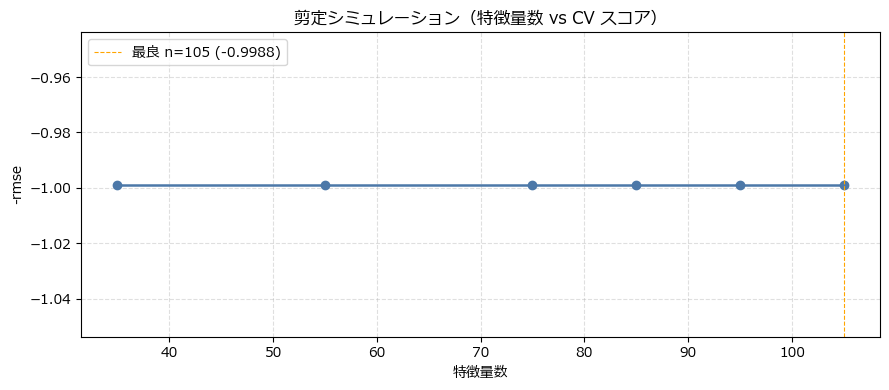

最適特徴量数: 105 (score=-0.9988)
✓ 保存: C:\Users\yuki2\Documents\ws\keiba-ai-pro\notebooks\reports\feature_pruning_report.csv


In [20]:
## ── Cell K: 剪定シミュレーション可視化 + CSV 保存 ─────────────────────────
# feature_inspection.ipynb Cell K より移行

fig_k, ax_k = plt.subplots(figsize=(9, 4))
ax_k.plot(pruning_sim_df["n_features"], pruning_sim_df["cv_mean"],
          marker="o", linewidth=1.8, color="#4C78A8")
ax_k.set_xlabel("特徴量数")
ax_k.set_ylabel(pruning_sim_df["cv_metric"].iloc[0])
ax_k.set_title("剪定シミュレーション（特徴量数 vs CV スコア）")
ax_k.grid(True, linestyle="--", alpha=0.4)

# 最良点マーク
_best_row = pruning_sim_df.loc[pruning_sim_df["cv_mean"].idxmax()]
ax_k.axvline(_best_row["n_features"], color="orange", linestyle="--", linewidth=0.8,
             label=f"最良 n={int(_best_row['n_features'])} ({float(_best_row['cv_mean']):.4f})")
ax_k.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "feature_pruning_sim.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"最適特徴量数: {int(_best_row['n_features'])} (score={float(_best_row['cv_mean']):.4f})")

# CSV 保存
_pruning_csv = REPORTS_DIR / "feature_pruning_report.csv"
pruning_sim_df.to_csv(_pruning_csv, index=False, encoding="utf-8-sig")
print(f"✓ 保存: {_pruning_csv}")


In [21]:
## ── OUT: feature_analysis.json → FEATURE_STORE ───────────────────────────
# feature_inspection.ipynb Cell OUT より移行
# 08_reporting.ipynb の M1 セルが読み込む中間データ

import json

feature_analysis_json = {
    "target"   : _target_fa,
    "created_at": datetime.now().isoformat() if 'datetime' in dir() else "",
    "n_features_total" : len(_feat_cols),
    "n_features_ranked": len(final_rank_df),
    # top-30 ランキング
    "top30_final_rank" : final_rank_df.head(30)[
        ["rank","feature","final_score","imp_score","uni_score","quality_score","group"]
    ].to_dict(orient="records"),
    # グループ貢献
    "group_scores" : group_df.to_dict(orient="records"),
    # 高相関ペア
    "high_corr_pairs" : high_corr_df.head(20).to_dict(orient="records"),
    # VIF top-10
    "high_vif" : vif_df.head(10).to_dict(orient="records"),
    # 剪定サマリー
    "pruning_sim" : pruning_sim_df.to_dict(orient="records"),
    "recommended_n_features": int(_best_row["n_features"]),
    # 品質サマリー
    "quality_summary" : {
        "n_nan_over20"  : int((quality_df["nan_%"] > 20).sum()),
        "n_outlier_over5": int((quality_df["outlier_%"] > 5).sum()),
        "n_leak_flag"   : int(quality_df["is_leak"].sum()),
    },
}

# FEATURE_STORE に保存
save_store(feature_analysis_json, FEATURE_STORE, "feature_analysis")

# JSON ファイルにも保存（08_reporting の M3 セルが読む）
_json_path = FEATURE_STORE / "feature_analysis.json"
_json_path.write_text(json.dumps(feature_analysis_json, ensure_ascii=False, indent=2, default=str),
                      encoding="utf-8")
print(f"✓ JSON 保存: {_json_path}")

# final_rank_df を pkl でも保存（08 がそのまま使える）
save_store(final_rank_df, REPORT_STORE, "final_rank_df")
print("\n── feature_analysis 完了 ──")
print(f"  top-1 feature : {final_rank_df.iloc[0]['feature']}  (score={final_rank_df.iloc[0]['final_score']})")
print(f"  推奨特徴量数  : {int(_best_row['n_features'])}")


  ✓ feature_store/feature_analysis.pkl  (4.6 KB)
✓ JSON 保存: C:\Users\yuki2\Documents\ws\keiba-ai-pro\notebooks\data\feature_store\feature_analysis.json
  ✓ report_store/final_rank_df.pkl  (11.0 KB)

── feature_analysis 完了 ──
  top-1 feature : recent_form_5race  (score=0.7621)
  推奨特徴量数  : 105
